# Nebula Brightness-Based Depth Map

Derives a depth map from `test_solved_nebula.fits` using background-subtracted luminance.

**Pipeline**
1. Load FITS & compute luminance (`luma_norm`)
2. Background modeling — Gaussian fit → `nebula_mask`, `luma_sub`
3. Transform comparison — applied to all pixels; depth map & histogram show nebula only
4. Scale factor study
5. Export `export/nebula_depth.png` (all pixels, background-subtracted)

In [1]:
import os
import copy
import json
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image
from astropy.io import fits
from scipy.optimize import curve_fit

## 1. Load FITS & compute luminance

In [2]:
NEBULA_FITS = "test_solved_nebula.fits"
EXPORT_DIR  = "export"

with fits.open(NEBULA_FITS) as hdul:
    raw = hdul[0].data.astype(np.float32)   # (3, H, W) or (H, W)
    print(f"FITS shape : {raw.shape}  dtype: {hdul[0].data.dtype}")

if raw.ndim == 3:
    # Rec.709 luminance weights
    luma = 0.2126 * raw[0] + 0.7152 * raw[1] + 0.0722 * raw[2]
else:
    luma = raw.copy()

luma      = np.clip(luma, 0, None)           # remove subtraction artifacts
luma_norm = luma / (luma.max() + 1e-9)       # [0, 1]

IMG_H, IMG_W = luma_norm.shape
print(f"Image size : {IMG_W} × {IMG_H}")
print(f"luma range : {luma_norm.min():.4f} – {luma_norm.max():.4f}")
print(f"Non-zero px: {(luma_norm > 0.001).sum():,} / {luma_norm.size:,}")

FITS shape : (3, 3000, 3000)  dtype: uint16
Image size : 3000 × 3000
luma range : 0.0000 – 1.0000
Non-zero px: 8,999,735 / 9,000,000


In [3]:
# ── Shared coordinate system (must match export_stars.ipynb) ────
BG_DIST_PC  = 10**3.5          # 3162.28 pc  →  z = bg_z_scene = 0
DEPTH_COEFF = 0.08
bg_z_scene  = 0
DEPTH_SCALE = DEPTH_COEFF * IMG_W / 2   # scene units per log10-pc unit

# ── Nebula physical parameters (from literature) ─────────────────
nebula_dist_pc      = 400.0   # distance to nebula center (pc) — set from literature
depth_nebula_parsec = 25.0    # line-of-sight physical depth (pc)

# ── Derived scene z coordinates (same log10 formula as stars) ────
#   z = -(log10(d_pc) - log10(BG_DIST_PC)) * DEPTH_SCALE + bg_z_scene
z_neb_center = -(np.log10(nebula_dist_pc) - np.log10(BG_DIST_PC)) * DEPTH_SCALE + bg_z_scene

z_near = -(np.log10(nebula_dist_pc - depth_nebula_parsec / 2) - np.log10(BG_DIST_PC)) * DEPTH_SCALE + bg_z_scene
z_far  = -(np.log10(nebula_dist_pc + depth_nebula_parsec / 2) - np.log10(BG_DIST_PC)) * DEPTH_SCALE + bg_z_scene

# Three.js: pos.z = nebula_z_offset + depth_01 * nebula_depth_scale
#   depth_01 = 0  →  back face (z_far,  faint background)
#   depth_01 = 1  →  front face (z_near, bright nebula core)
nebula_z_offset    = z_far
nebula_depth_scale = z_near - z_far    # always > 0  (closer = larger z)

print(f"DEPTH_SCALE        = {DEPTH_SCALE:.1f}  scene units / log10-pc")
print(f"z_neb_center       = {z_neb_center:.4f}")
print(f"z_far  (back face) = {z_far:.4f}")
print(f"z_near (near face) = {z_near:.4f}")
print(f"nebula_depth_scale = {nebula_depth_scale:.6f}  scene units")
print(f"(star z range: -197 to +233 for reference)")

DEPTH_SCALE        = 120.0  scene units / log10-pc
z_neb_center       = 107.7528
z_far  (back face) = 106.1491
z_near (near face) = 109.4074
nebula_depth_scale = 3.258270  scene units
(star z range: -197 to +233 for reference)


## 2. Background pixel modeling (Gaussian fit)

Fit a Gaussian to the background peak in the brightness histogram.  
Only bins up to `2 × mode_position` are used for the fit, isolating the background peak from the nebula tail.

Outputs used downstream:
- `mu_fit`, `sigma_fit` — background Gaussian parameters
- `threshold` — `mu_fit + DETECT_THRESH × sigma_fit`
- `nebula_mask` / `bg_mask` — per-pixel class labels
- `luma_sub` — globally background-subtracted luminance `[0, 1]`

Gaussian fit :  μ = 0.14069   σ = 0.021637
Threshold (3.0σ): 0.20560
Nebula px    : 654,152 / 9,000,000  (7.3%)


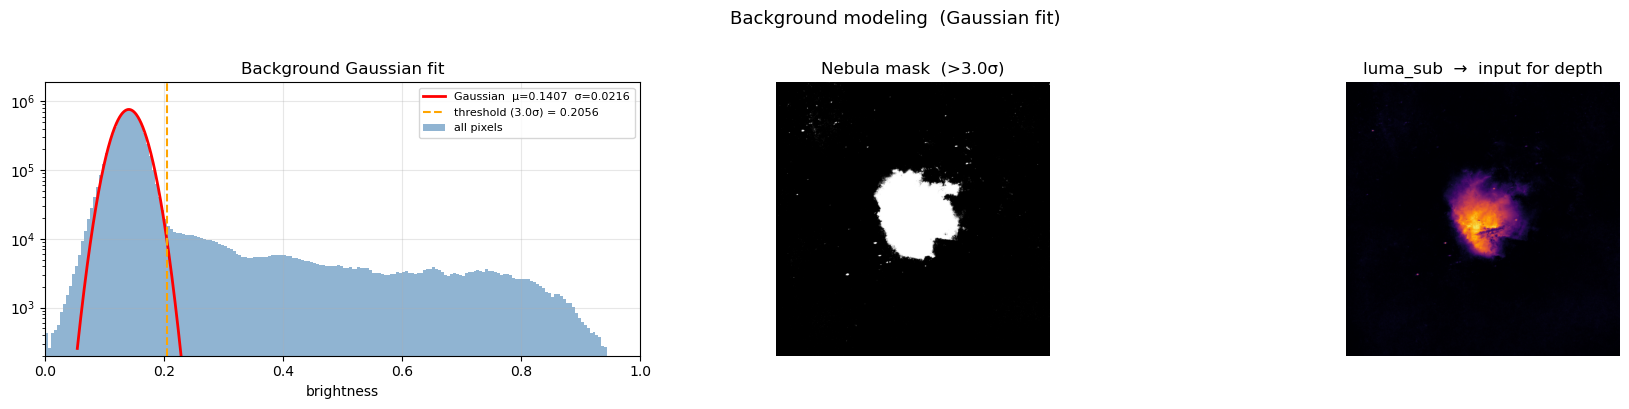

In [4]:
DETECT_THRESH = 3.0   # σ above background Gaussian to flag as nebula
N_BINS        = 200   # fewer bins → cleaner bars

# Histogram over full [0, 1] range
counts, edges = np.histogram(luma_norm.ravel(), bins=N_BINS, range=(0, 1))
centers = (edges[:-1] + edges[1:]) / 2
bw      = edges[1] - edges[0]

# Fit only the background peak: bins up to 2× the mode position
peak_idx = np.argmax(counts)
fit_mask = centers <= centers[peak_idx] * 2

def gaussian(x, amp, mu, sigma):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

p0 = [counts[peak_idx], centers[peak_idx], 1e-2]
popt, _ = curve_fit(gaussian, centers[fit_mask], counts[fit_mask], p0=p0)
amp_fit, mu_fit, sigma_fit = float(popt[0]), float(popt[1]), abs(float(popt[2]))

threshold   = mu_fit + DETECT_THRESH * sigma_fit
nebula_mask = luma_norm > threshold
bg_mask     = ~nebula_mask

# Background subtraction: shift by fitted mean, re-normalise to [0, 1]
luma_sub  = np.clip(luma_norm - mu_fit, 0, None)
luma_sub /= luma_sub.max() + 1e-9

print(f"Gaussian fit :  μ = {mu_fit:.5f}   σ = {sigma_fit:.6f}")
print(f"Threshold ({DETECT_THRESH}σ): {threshold:.5f}")
print(f"Nebula px    : {nebula_mask.sum():,} / {luma_norm.size:,}  ({nebula_mask.mean()*100:.1f}%)")

# ── Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Histogram zoomed to background region; x_fit clipped to ±4σ so log(0) is avoided
x_lo  = max(0.0, mu_fit - 4 * sigma_fit)
x_hi  = mu_fit + 6 * sigma_fit          # comfortably past threshold
x_fit = np.linspace(x_lo, x_hi, 400)

ax = axes[0]
ax.bar(centers, counts, width=bw, color='steelblue', alpha=0.6, label='all pixels')
ax.plot(x_fit, gaussian(x_fit, amp_fit, mu_fit, sigma_fit),
        color='red', linewidth=2, label=f'Gaussian  μ={mu_fit:.4f}  σ={sigma_fit:.4f}')
ax.axvline(threshold, color='orange', linestyle='--', linewidth=1.5,
           label=f'threshold ({DETECT_THRESH}σ) = {threshold:.4f}')
ax.set_yscale('log')
ax.set_xlim(0, 1)
ax.set_ylim(200,)
ax.set_xlabel("brightness"); ax.set_title("Background Gaussian fit")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

axes[1].imshow(nebula_mask, origin='upper', cmap='gray')
axes[1].set_title(f"Nebula mask  (>{DETECT_THRESH}σ)"); axes[1].axis('off')

axes[2].imshow(luma_sub, origin='upper', cmap='inferno')
axes[2].set_title("luma_sub  →  input for depth"); axes[2].axis('off')

plt.suptitle("Background modeling  (Gaussian fit)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3. Transform comparison

Each transform is applied to **all pixels** (including background) of `luma_sub`.  
- **Depth map**: background pixels masked to black (NaN), nebula colored by depth value  
- **Histogram**: only nebula pixels, bars colored by their depth value using the same colormap

In [5]:
transforms = {
    "linear":        lambda b: b,
    "sqrt (γ=0.5)":  lambda b: b ** 0.5,
    "cbrt (γ=0.33)": lambda b: b ** 0.33,
    "log":           lambda b: np.log10(1.0 + b * 99.0) / np.log10(100.0),
    "power γ=2":     lambda b: b ** 2.0,
    "threshold":     lambda b: np.where(b > 0.05, b, 0.0),
}

linear                z [ 106.3952,  109.4074]  center=107.7528  nebula=654,152px
sqrt (γ=0.5)          z [ 107.0446,  109.4074]  center=107.7528  nebula=654,152px
cbrt (γ=0.33)         z [ 107.5384,  109.4074]  center=107.7528  nebula=654,152px
log                   z [ 107.6615,  109.4074]  center=107.7528  nebula=654,152px
power γ=2             z [ 106.1677,  109.4074]  center=107.7528  nebula=654,152px
threshold             z [ 106.3952,  109.4074]  center=107.7528  nebula=654,152px


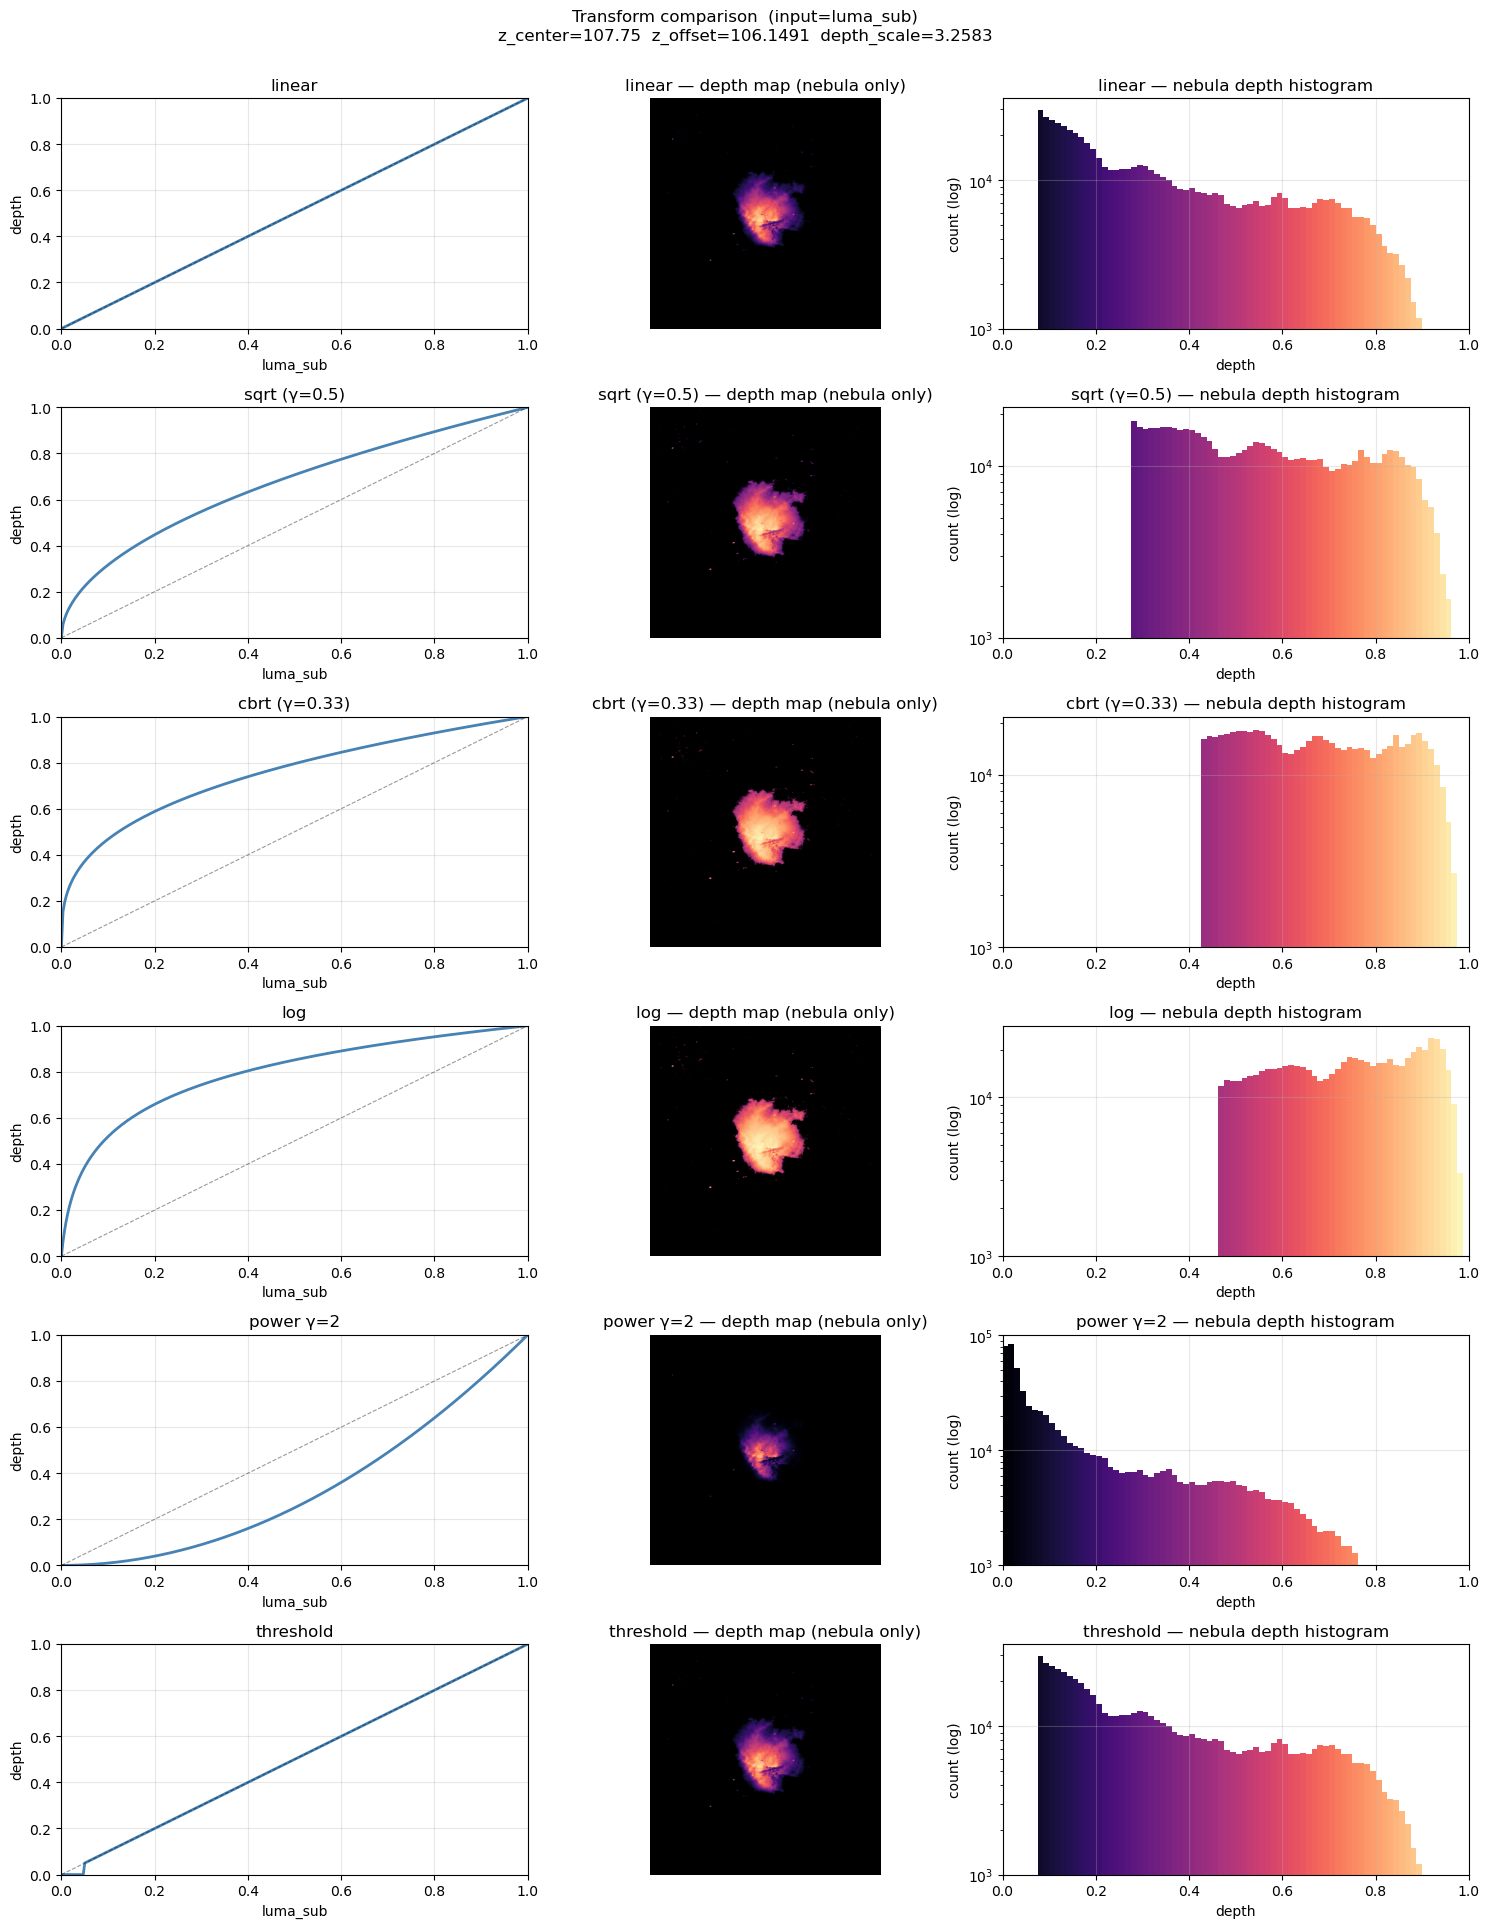

In [6]:
CMAP_DEPTH = 'magma'

_cmap     = plt.get_cmap(CMAP_DEPTH)
_cmap_img = copy.copy(_cmap)
_cmap_img.set_bad('black')   # NaN → black for background pixels

x_c = np.linspace(0, 1, 300)
n_t = len(transforms)
fig, axes = plt.subplots(n_t, 3, figsize=(15, n_t * 3.2))

for row, (name, fn) in enumerate(transforms.items()):
    depth = fn(luma_sub)   # transform applied to ALL pixels (incl. background)

    # ── Col 0: transfer curve ─────────────────────────────────
    ax0 = axes[row, 0]
    ax0.plot(x_c, fn(x_c), color='steelblue', linewidth=2)
    ax0.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.4)
    ax0.set_xlim(0, 1); ax0.set_ylim(0, 1)
    ax0.set_xlabel("luma_sub"); ax0.set_ylabel("depth")
    ax0.set_title(f"{name}"); ax0.grid(True, alpha=0.3)

    # ── Col 1: depth map — background masked to black ─────────
    depth_vis = depth.copy().astype(float)
    depth_vis[bg_mask] = np.nan
    ax1 = axes[row, 1]
    ax1.imshow(depth_vis, origin='upper', cmap=_cmap_img, vmin=0, vmax=1)
    ax1.set_title(f"{name} — depth map (nebula only)"); ax1.axis('off')

    # ── Col 2: histogram colored by depth value (same cmap) ───
    ax2 = axes[row, 2]
    depth_neb = depth[nebula_mask]
    cnts, bedges = np.histogram(depth_neb, bins=80, range=(0, 1))
    bw       = bedges[1] - bedges[0]
    bcenters = (bedges[:-1] + bedges[1:]) / 2
    bars = ax2.bar(bcenters, cnts, width=bw, align='center', log=True, edgecolor='none')
    for bar, bc in zip(bars, bcenters):
        bar.set_facecolor(_cmap(bc))
    ax2.set_xlim(0, 1)
    ax2.set_ylim(1000, cnts.max() * 1.2)
    ax2.set_xlabel("depth"); ax2.set_ylabel("count (log)")
    ax2.set_title(f"{name} — nebula depth histogram"); ax2.grid(True, alpha=0.3)

    # z stats using calibrated coordinate system
    z_sc = nebula_z_offset + depth[nebula_mask] * nebula_depth_scale
    print(f"{name:<20}  z [{z_sc.min():>9.4f}, {z_sc.max():>9.4f}]  "
          f"center={z_neb_center:.4f}  nebula={nebula_mask.sum():,}px")

plt.suptitle(
    f"Transform comparison  (input=luma_sub)\n"
    f"z_center={z_neb_center:.2f}  z_offset={nebula_z_offset:.4f}  depth_scale={nebula_depth_scale:.4f}",
    fontsize=12, y=1.002
)
plt.tight_layout()
plt.show()

### 3b. 3D scatter preview — all transforms (nebula pixels only)

One subplot per transform, all sharing the same subsampled nebula pixel set.

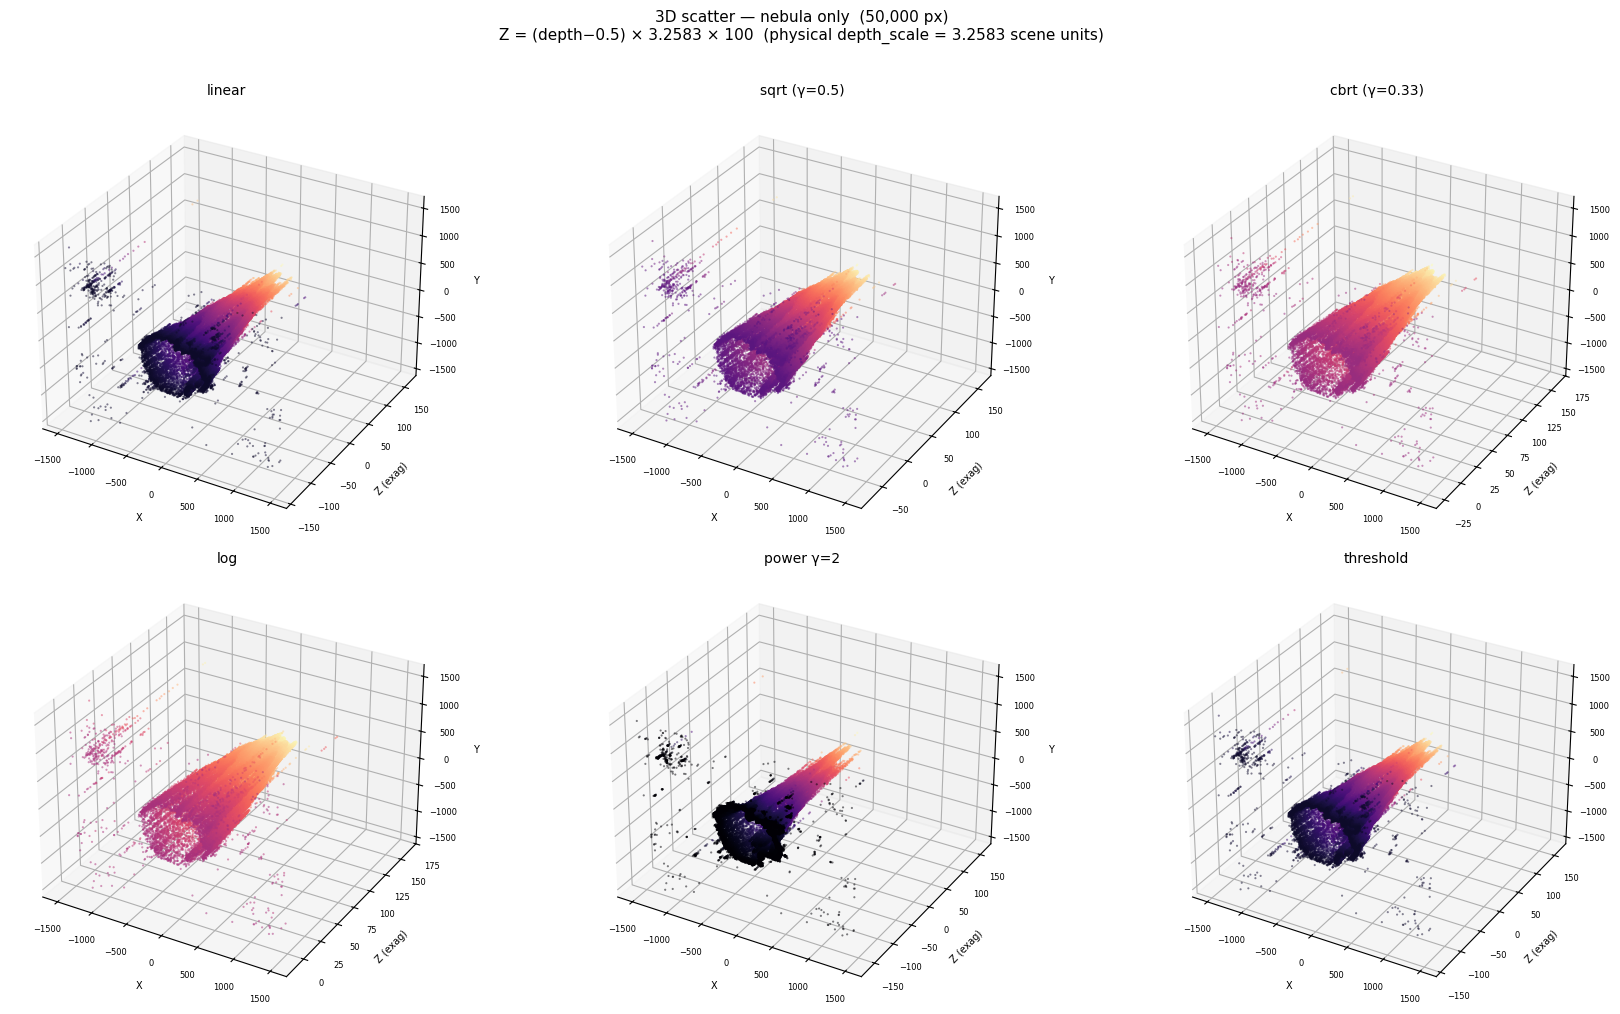

In [7]:
SCATTER_EXAG = 100   # visual Z exaggeration (physical depth is tiny)
N_SCATTER    = 50_000

# Pre-sample nebula pixel indices once — reused for every transform
ys_fg, xs_fg = np.where(nebula_mask)
rng  = np.random.default_rng(42)
idx  = rng.choice(len(ys_fg), min(N_SCATTER, len(ys_fg)), replace=False)
xs_s, ys_s = xs_fg[idx], ys_fg[idx]

sc_x = xs_s - IMG_W / 2.0
sc_y = -(ys_s - IMG_H / 2.0)   # flip Y: pixel-down → scene-up

n_t   = len(transforms)
ncols = 3
nrows = (n_t + ncols - 1) // ncols
fig   = plt.figure(figsize=(6 * ncols, 5 * nrows))

for i, (name, fn) in enumerate(transforms.items()):
    depth_3d = fn(luma_sub)
    # Centre relative to z_neb_center, apply physical scale × visual exaggeration
    sc_z = (depth_3d[ys_s, xs_s] - 0.5) * nebula_depth_scale * SCATTER_EXAG
    col  = depth_3d[ys_s, xs_s]

    ax = fig.add_subplot(nrows, ncols, i + 1, projection='3d')
    ax.scatter(sc_x, sc_z, sc_y, c=col, cmap=CMAP_DEPTH,
               s=0.3, alpha=0.5, vmin=0, vmax=1)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("X", fontsize=7); ax.tick_params(labelsize=6)
    ax.set_ylabel("Z (exag)", fontsize=7)
    ax.set_zlabel("Y", fontsize=7)

plt.suptitle(
    f"3D scatter — nebula only  ({len(idx):,} px)\n"
    f"Z = (depth−0.5) × {nebula_depth_scale:.4f} × {SCATTER_EXAG}  "
    f"(physical depth_scale = {nebula_depth_scale:.4f} scene units)",
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()

## 4. Calibrated z-position overview

Shows where the nebula sits in scene-z relative to the star field, using the
physically-derived `nebula_z_offset` and `nebula_depth_scale` (from Section 1).

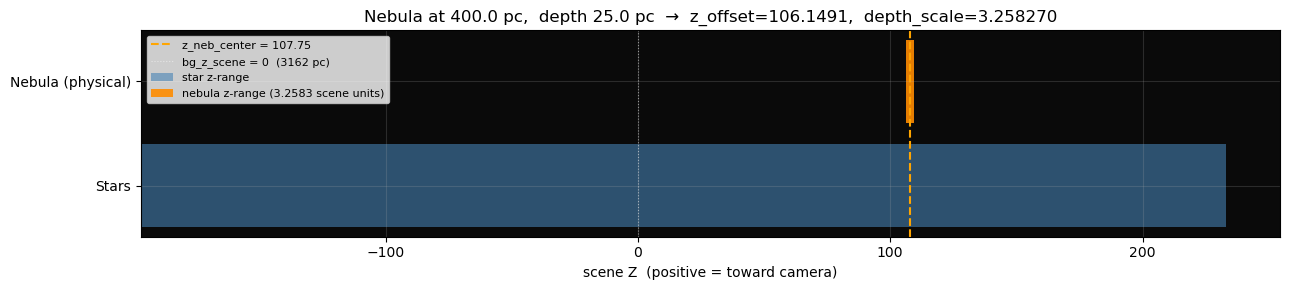


Star z range    : [-197, 233]  span = 430
Nebula z center : 107.7528
Nebula z range  : [106.149126, 109.407395]  span = 3.258270
Nebula/star depth ratio: 0.75774%


In [8]:
STAR_Z_NEAR = 233    # from export_stars.ipynb output
STAR_Z_FAR  = -197

fig, ax = plt.subplots(figsize=(13, 3))
ax.set_facecolor('#0a0a0a')

ax.barh(["Stars"],
        [STAR_Z_NEAR - STAR_Z_FAR], left=STAR_Z_FAR,
        color='steelblue', alpha=0.6, label='star z-range')

ax.barh(["Nebula (physical)"],
        [nebula_depth_scale], left=nebula_z_offset,
        color='darkorange', alpha=0.9,
        label=f'nebula z-range ({nebula_depth_scale:.4f} scene units)')

ax.axvline(z_neb_center, color='orange', linewidth=1.5, linestyle='--',
           label=f'z_neb_center = {z_neb_center:.2f}')
ax.axvline(0, color='white', linewidth=0.8, linestyle=':', alpha=0.5,
           label=f'bg_z_scene = 0  ({BG_DIST_PC:.0f} pc)')

ax.set_xlabel("scene Z  (positive = toward camera)")
ax.set_title(
    f"Nebula at {nebula_dist_pc} pc,  depth {depth_nebula_parsec} pc  →  "
    f"z_offset={nebula_z_offset:.4f},  depth_scale={nebula_depth_scale:.6f}"
)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f"\nStar z range    : [{STAR_Z_FAR}, {STAR_Z_NEAR}]  span = {STAR_Z_NEAR - STAR_Z_FAR}")
print(f"Nebula z center : {z_neb_center:.4f}")
print(f"Nebula z range  : [{nebula_z_offset:.6f}, {nebula_z_offset + nebula_depth_scale:.6f}]  "
      f"span = {nebula_depth_scale:.6f}")
print(f"Nebula/star depth ratio: {nebula_depth_scale / (STAR_Z_NEAR - STAR_Z_FAR) * 100:.5f}%")

## 5. Export

Set `CHOSEN_TRANSFORM` after reviewing Sections 3 & 4, then run this cell.

**Outputs:**
- `export/nebula_depth.png` — grayscale depth map (all pixels; background → 0, bright core → 255)
- `export/nebula_meta.json` — calibrated z parameters consumed by Three.js
- `export/nebula.png` — RGB color (original − star-only), for the flat nebula plane and RGBD color layer

Saved     : export\nebula_depth.png  (3000×3000 px, all pixels)
Transform : log  on luma_sub
Saved     : export\nebula_meta.json
  nebula_z_offset    = 106.149126
  nebula_depth_scale = 3.258270
  nebula_z_center    = 107.7528


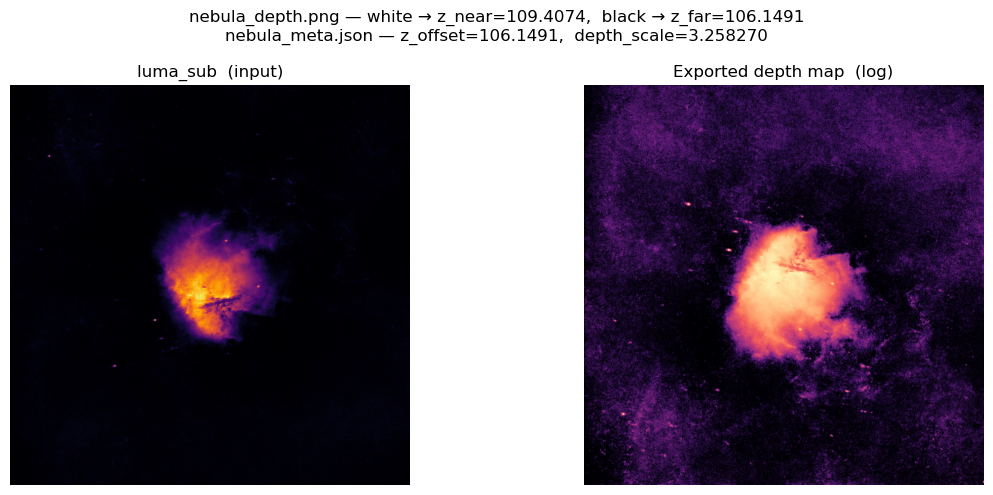

In [9]:
# ── TUNING PARAM ────────────────────────────────────────────────
CHOSEN_TRANSFORM = "log"
# ────────────────────────────────────────────────────────────────

# All pixels transformed (background near 0 → stays at z_far)
depth_final   = transforms[CHOSEN_TRANSFORM](luma_sub)

# FITS row-0 = bottom; PNG row-0 = top → flip Y to match nebula.png orientation
depth_flipped = np.flipud(depth_final)
depth_uint8   = (depth_flipped * 255).astype(np.uint8)

png_path = os.path.join(EXPORT_DIR, "nebula_depth.png")
Image.fromarray(depth_uint8, mode="L").save(png_path)
print(f"Saved     : {png_path}  ({IMG_W}×{IMG_H} px, all pixels)")
print(f"Transform : {CHOSEN_TRANSFORM}  on luma_sub")

# ── Export calibrated metadata for Three.js ──────────────────────
nebula_meta_out = {
    "nebula_z_offset":     round(float(nebula_z_offset),    4),
    "nebula_depth_scale":  round(float(nebula_depth_scale), 6),
    "nebula_z_center":     round(float(z_neb_center),       4),
    "nebula_dist_pc":      nebula_dist_pc,
    "depth_nebula_parsec": depth_nebula_parsec,
    "transform":           CHOSEN_TRANSFORM,
    "bg_dist_pc":          BG_DIST_PC,
    "bg_z_scene":          bg_z_scene,
}
meta_path = os.path.join(EXPORT_DIR, "nebula_meta.json")
with open(meta_path, "w") as f:
    json.dump(nebula_meta_out, f, separators=(",", ":"), indent=2)
print(f"Saved     : {meta_path}")
print(f"  nebula_z_offset    = {nebula_z_offset:.6f}")
print(f"  nebula_depth_scale = {nebula_depth_scale:.6f}")
print(f"  nebula_z_center    = {z_neb_center:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(luma_sub, origin='upper', cmap='inferno')
axes[0].set_title("luma_sub  (input)"); axes[0].axis('off')
axes[1].imshow(depth_flipped, origin='upper', cmap='magma', vmin=0, vmax=1)
axes[1].set_title(f"Exported depth map  ({CHOSEN_TRANSFORM})"); axes[1].axis('off')
plt.suptitle(
    f"nebula_depth.png — white → z_near={z_near:.4f},  black → z_far={z_far:.4f}\n"
    f"nebula_meta.json — z_offset={nebula_z_offset:.4f},  depth_scale={nebula_depth_scale:.6f}"
)
plt.tight_layout()
plt.show()

### 5b. Export nebula.png (original − star-only)

Subtracts the star-only FITS from the original to isolate the nebula in RGB.

**Inputs:** `test_solved.fits`, `test_solved_star.fits`  
**Output:** `export/nebula.png`

Orig FITS: (3, 3000, 3000)  dtype: >f4
Star FITS: (3, 3000, 3000)  dtype: uint16
Saved: export\nebula.png  (3000×3000 px)


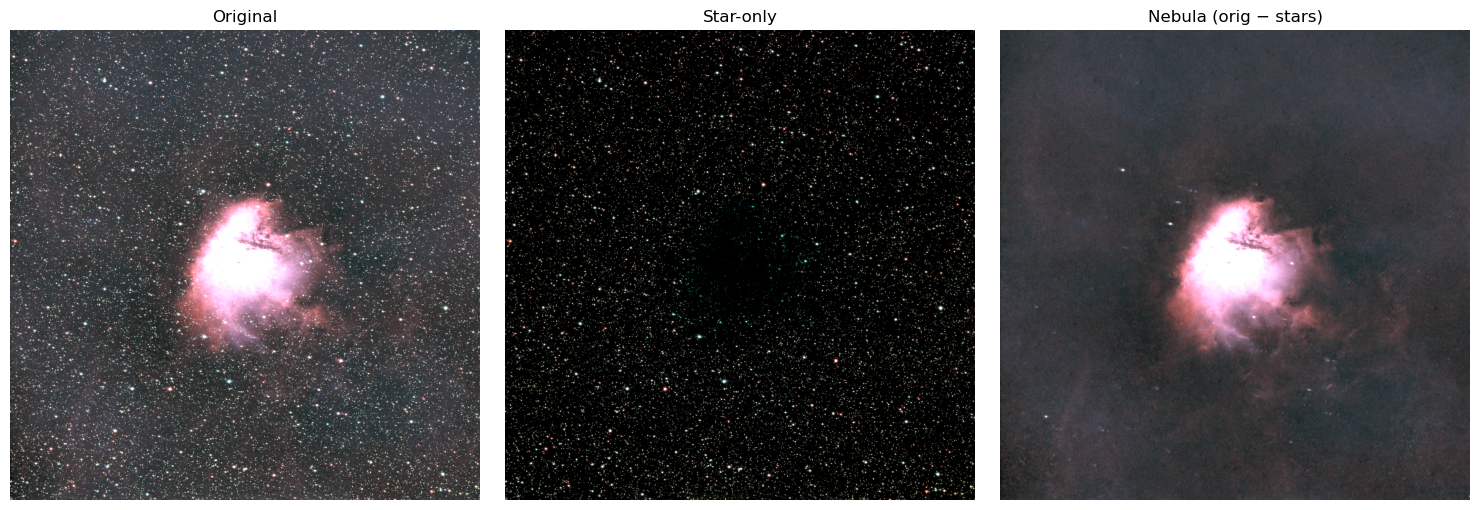

In [10]:
ORIG_FITS_PATH = "test_solved.fits"
STAR_FITS_PATH = "test_solved_star.fits"

with fits.open(ORIG_FITS_PATH) as hdul:
    orig_data = hdul[0].data.astype(np.float32)
    print(f"Orig FITS: {orig_data.shape}  dtype: {hdul[0].data.dtype}")

with fits.open(STAR_FITS_PATH) as hdul:
    star_data = hdul[0].data.astype(np.float32)
    print(f"Star FITS: {star_data.shape}  dtype: {hdul[0].data.dtype}")

if orig_data.ndim == 3:
    orig_rgb_f = np.transpose(orig_data / (orig_data.max() + 1e-9), (1, 2, 0))  # (H, W, 3)
    star_rgb_f = np.transpose(star_data / (star_data.max() + 1e-9), (1, 2, 0))  # (H, W, 3)
    nebula_rgb = np.clip(orig_rgb_f - star_rgb_f, 0.0, 1.0)
else:
    orig_luma  = orig_data / (orig_data.max() + 1e-9)
    star_luma  = star_data / (star_data.max() + 1e-9)
    nebula_rgb = np.stack([np.clip(orig_luma - star_luma, 0.0, 1.0)] * 3, axis=-1)
    orig_rgb_f, star_rgb_f = np.stack([orig_luma] * 3, -1), np.stack([star_luma] * 3, -1)

nebula_uint8 = (nebula_rgb * 255).astype(np.uint8)

nebula_path = os.path.join(EXPORT_DIR, "nebula.png")
Image.fromarray(nebula_uint8, mode="RGB").save(nebula_path)
print(f"Saved: {nebula_path}  ({nebula_uint8.shape[1]}×{nebula_uint8.shape[0]} px)")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, title in zip(axes,
                           [orig_rgb_f, star_rgb_f, nebula_rgb],
                           ["Original", "Star-only", "Nebula (orig − stars)"]):
    ax.imshow(np.clip(img * 2, 0, 1), origin="lower")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()